In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, shapiro, kruskal, mannwhitneyu, tukey_hsd, ttest_ind
from statsmodels.stats.oneway import anova_oneway

[Swap(5), Swap(4), Swap(3), Swap(2), Swap(1)]

[Swap(1), Swap(2), Swap(3), Swap(4), Swap(5)]

In [2]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [3]:
# Deterministic
filename = 'FX_values_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]

# Stochastic
filename = 'FX_values_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]

## Deterministic

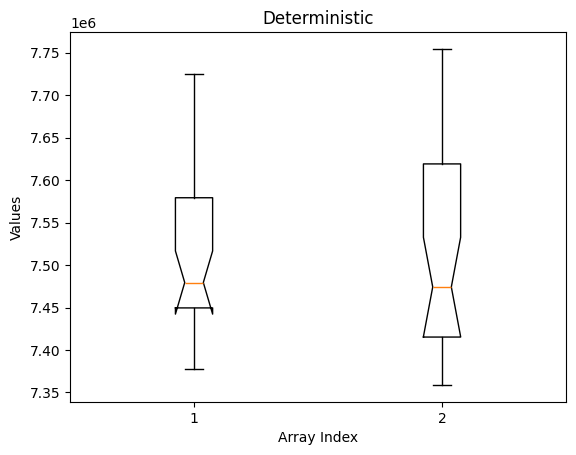

In [4]:
filename = 'FX_values_0.npz'
plot_boxplots(filename, "Deterministic")

In [5]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a0))
print(shapiro(b0))

ShapiroResult(statistic=0.9033257610947445, pvalue=0.010138592381606876)
ShapiroResult(statistic=0.8913128331210763, pvalue=0.005183170572016429)


Neither of them is normally distributed.

In [6]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=465.5, pvalue=0.8243372344129953)


No difference between a and b.

## Stochastic

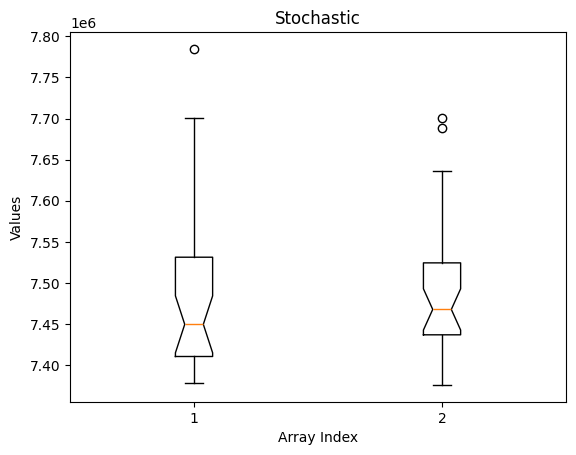

In [7]:
filename = 'FX_values_1.npz'
plot_boxplots(filename, "Stochastic")

In [8]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a1))
print(shapiro(b1))

ShapiroResult(statistic=0.8267240406554502, pvalue=0.00020953831496900145)
ShapiroResult(statistic=0.9162561664234955, pvalue=0.021470289944219338)


Neither of them is normally distributed.

In [9]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a1, b1, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=387.0, pvalue=0.3550844914621265)


No difference between a and b.

# Deterministic x Stochastic

In [11]:
# H0: the distribution underlying the two samples is the same

print(f"a0 vs a1: {mannwhitneyu(a0, a1, alternative='two-sided')}")
print(f"b0 vs b1: {mannwhitneyu(b0, b1, alternative='two-sided')}")

a0 vs a1: MannwhitneyuResult(statistic=571.0, pvalue=0.07456849739349185)
b0 vs b1: MannwhitneyuResult(statistic=495.0, pvalue=0.5101038162474929)


No difference.